# Feature Engineering & Data Preprocessing
### A Practical, Visual Guide — From Raw Data to Model-Ready Features

---

This notebook covers the **essential preprocessing and feature engineering** techniques every data scientist needs.  
We'll go step by step — theory first, then code, then visualization — so every concept clicks.

**What we'll cover:**

1. **Data Cleaning** — handling missing values, duplicates, outliers  
2. **Encoding Categorical Variables** — label, one-hot, ordinal, target encoding  
3. **Feature Scaling** — standardization, normalization, robust scaling  
4. **Feature Transformation** — log, power, Box-Cox, Yeo-Johnson  
5. **Feature Creation** — interaction features, polynomial features, date/time features, binning  
6. **Feature Selection** — filter, wrapper, and embedded methods  
7. **Putting It All Together** — sklearn Pipelines  
8. **Interview Q&A**

---


## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Prettier plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

print("✅ All imports successful!")


✅ All imports successful!


---
# 1. Data Cleaning

Before any modeling, we need **clean data**. Real-world datasets almost always contain:
- **Missing values** (NaN, null, blank)
- **Duplicate rows**
- **Outliers** (extreme values that distort statistics)

> **Rule of thumb:** Spend 80% of your time on data cleaning and preparation — it has the biggest impact on model quality.

---
## 1.1 Handling Missing Data

### Why do values go missing?

| Type | Meaning | Example |
|------|---------|---------|
| **MCAR** (Missing Completely At Random) | Missingness has no pattern | A sensor randomly fails |
| **MAR** (Missing At Random) | Missingness depends on *observed* data | Older patients skip a survey question |
| **MNAR** (Missing Not At Random) | Missingness depends on the *missing value itself* | High-income people refuse to report income |

**Why does this matter?**
- **MCAR**: Safe to drop rows (but you lose data).
- **MAR**: Imputation using related features works well.
- **MNAR**: Hardest case — may need domain knowledge or a missingness indicator feature.


### Let's create a sample dataset with missing values

In [2]:
# Create a realistic dataset
np.random.seed(42)
n = 200

data = pd.DataFrame({
    'age': np.random.randint(18, 70, n).astype(float),
    'income': np.random.lognormal(10.5, 0.8, n),
    'education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n, 
                                   p=[0.3, 0.4, 0.2, 0.1]),
    'experience_years': np.random.randint(0, 30, n).astype(float),
    'city': np.random.choice(['New York', 'London', 'Berlin', 'Tokyo', 'Sydney'], n),
    'satisfaction': np.random.randint(1, 11, n).astype(float),
})

# Inject missing values
rng = np.random.default_rng(42)
data.loc[rng.choice(n, 20, replace=False), 'age'] = np.nan
data.loc[rng.choice(n, 35, replace=False), 'income'] = np.nan
data.loc[rng.choice(n, 15, replace=False), 'experience_years'] = np.nan
data.loc[rng.choice(n, 10, replace=False), 'education'] = np.nan

print(f"Dataset shape: {data.shape}")
print(f"\nMissing values:\n{data.isnull().sum()}")
print(f"\nMissing value percentages:\n{(data.isnull().mean() * 100).round(1)}%")
data.head(10)


Dataset shape: (200, 6)

Missing values:
age                 20
income              35
education           10
experience_years    15
city                 0
satisfaction         0
dtype: int64

Missing value percentages:
age                 10.0
income              17.5
education            5.0
experience_years     7.5
city                 0.0
satisfaction         0.0
dtype: float64%


,age,income,education,experience_years,city,satisfaction
0,56.0,40199.498182,PhD,1.0,Sydney,4.0
1,69.0,13365.673522,High School,12.0,Tokyo,6.0
2,46.0,172145.011651,Bachelor,29.0,Sydney,6.0
3,32.0,32123.105060,PhD,10.0,London,8.0
4,60.0,17578.119892,Bachelor,10.0,Tokyo,1.0
5,25.0,18884.876129,NaN,15.0,Berlin,7.0
6,38.0,24673.914144,NaN,10.0,Tokyo,1.0
7,56.0,NaN,Bachelor,NaN,New York,7.0
8,36.0,6813.902329,Master,14.0,Tokyo,3.0
9,40.0,99806.882676,High School,24.0,New York,8.0


### Visualizing Missing Data Patterns

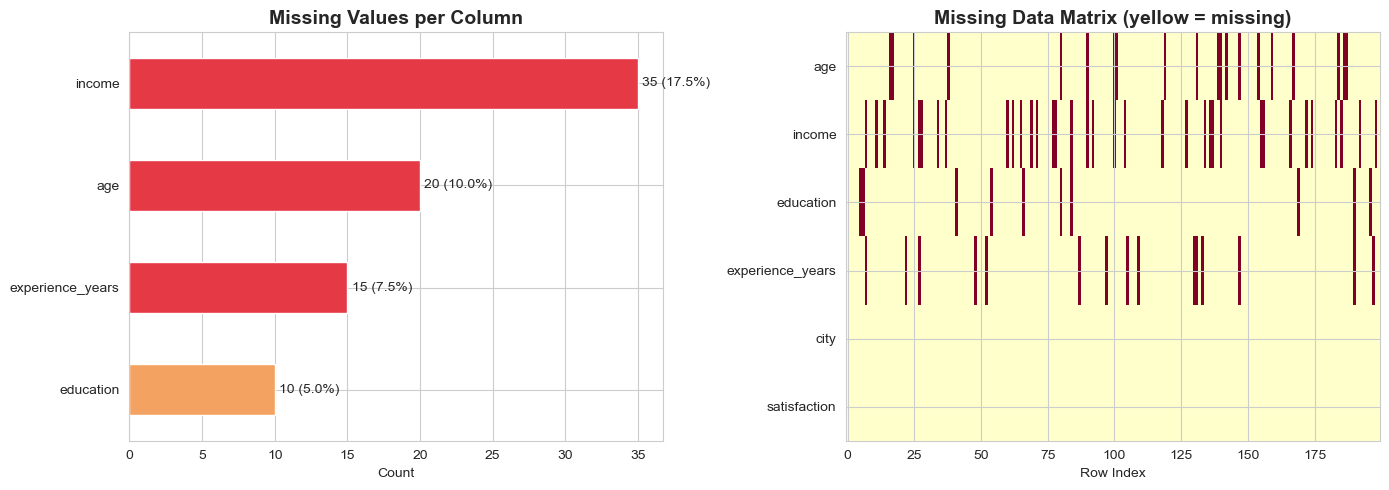

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing values
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
colors = ['#f4a261' if v < 15 else '#e63946' for v in missing.values]
missing.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Missing Values per Column', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(missing.values):
    axes[0].text(v + 0.3, i, f'{v} ({v/len(data)*100:.1f}%)', va='center', fontsize=10)

# Missing data matrix (heatmap style)
ax = axes[1]
missing_matrix = data.isnull().astype(int)
ax.imshow(missing_matrix.values.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(data.columns)))
ax.set_yticklabels(data.columns)
ax.set_xlabel('Row Index')
ax.set_title('Missing Data Matrix (yellow = missing)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### Imputation Strategies

| Strategy | When to Use | Pros | Cons |
|----------|------------|------|------|
| **Drop rows** | MCAR, very few missing | Simple | Loses data |
| **Mean / Median** | Numerical, MCAR | Fast, simple | Distorts distribution |
| **Mode** | Categorical | Simple | Ignores relationships |
| **KNN Imputer** | MAR, features are related | Captures local patterns | Slow on large data |
| **Iterative (MICE)** | MAR, complex relationships | Most accurate | Slow, complex |
| **Constant / Flag** | MNAR, missingness is informative | Preserves signal | Adds features |


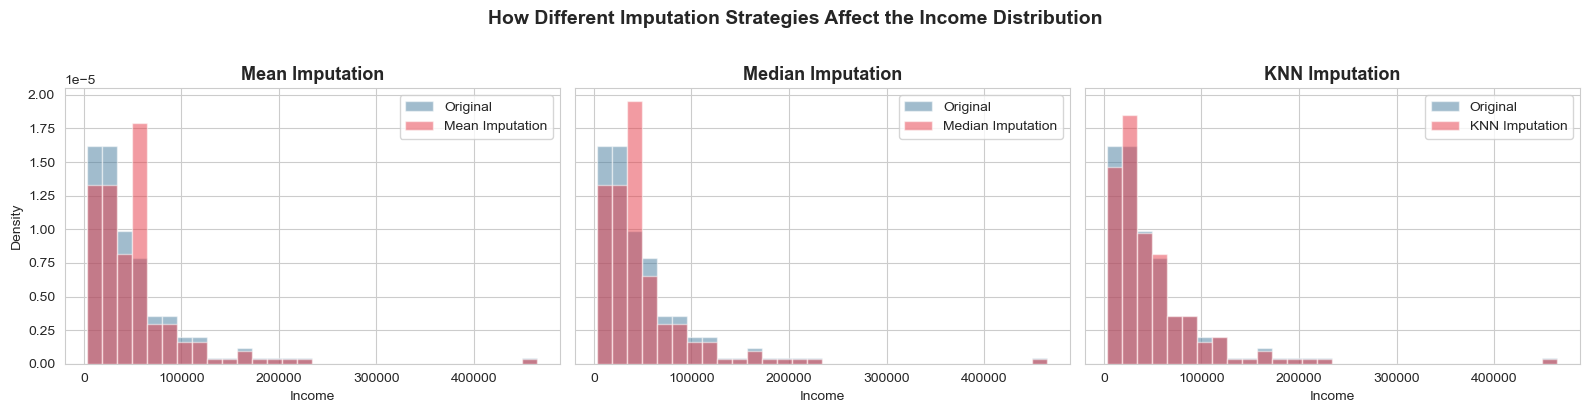

💡 Observation: Mean imputation creates a spike at the mean.
   Median imputation is more robust to skew.
   KNN imputation preserves the shape best because it uses neighboring rows.


In [4]:
from sklearn.impute import SimpleImputer, KNNImputer

# Make a copy to compare strategies
df = data.copy()

# --- Strategy 1: Mean/Median imputation ---
mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')

# --- Strategy 2: KNN imputation ---
knn_imputer = KNNImputer(n_neighbors=5)

# Compare on the 'income' column (which is skewed)
income_original = data['income'].dropna()

# Mean
income_mean = data[['income']].copy()
income_mean['income'] = mean_imputer.fit_transform(income_mean)

# Median
income_median = data[['income']].copy()
income_median['income'] = median_imputer.fit_transform(income_median)

# KNN (using age + experience as neighbors)
numeric_cols = ['age', 'income', 'experience_years']
df_knn = data[numeric_cols].copy()
df_knn_imputed = pd.DataFrame(knn_imputer.fit_transform(df_knn), columns=numeric_cols)

# Visualize the difference
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (title, vals) in zip(axes, [
    ('Mean Imputation', income_mean['income']),
    ('Median Imputation', income_median['income']),
    ('KNN Imputation', df_knn_imputed['income']),
]):
    ax.hist(income_original, bins=30, alpha=0.5, label='Original', color='#457b9d', density=True)
    ax.hist(vals, bins=30, alpha=0.5, label=title, color='#e63946', density=True)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_xlabel('Income')

axes[0].set_ylabel('Density')
plt.suptitle('How Different Imputation Strategies Affect the Income Distribution', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Observation: Mean imputation creates a spike at the mean.")
print("   Median imputation is more robust to skew.")
print("   KNN imputation preserves the shape best because it uses neighboring rows.")


### Handling missing categorical data

In [5]:
# For categorical columns: use mode (most frequent) or a special "Unknown" category
cat_imputer = SimpleImputer(strategy='most_frequent')
data['education'] = cat_imputer.fit_transform(data[['education']]).ravel()

print(f"Education missing after imputation: {data['education'].isnull().sum()}")
print(f"Value counts:\n{data['education'].value_counts()}")


Education missing after imputation: 0
Value counts:
education
Bachelor       85
High School    56
Master         36
PhD            23
Name: count, dtype: int64


### Adding a Missingness Indicator (useful when MNAR)

Sometimes the *fact* that a value is missing is itself informative. For example, if high-income people refuse to report income, adding a binary flag `income_was_missing` captures this signal.


In [6]:
# Create missingness indicator BEFORE imputing
data['income_missing'] = data['income'].isnull().astype(int)
print(f"income_missing distribution:\n{data['income_missing'].value_counts()}")
print("\n💡 Now the model can learn: 'when income is missing, the outcome tends to be X'")


income_missing distribution:
income_missing
0    165
1     35
Name: count, dtype: int64

💡 Now the model can learn: 'when income is missing, the outcome tends to be X'


---
## 1.2 Handling Duplicates

Duplicate rows can bias your model by giving certain observations more weight.


In [7]:
# Add some duplicate rows for demonstration
df_dup = pd.concat([data, data.iloc[:5]], ignore_index=True)
print(f"Before removing duplicates: {len(df_dup)} rows")

# Find duplicates
dupes = df_dup.duplicated()
print(f"Duplicate rows found: {dupes.sum()}")

# Remove
df_dup = df_dup.drop_duplicates()
print(f"After removing duplicates: {len(df_dup)} rows")


Before removing duplicates: 205 rows
Duplicate rows found: 5
After removing duplicates: 200 rows


---
## 1.3 Outlier Detection & Handling

### What is an outlier?
A data point that lies **far away** from the rest of the distribution. Not all outliers are errors — some are real but extreme observations.

### Common Detection Methods

**1. Z-Score Method**  
$$z = \frac{x - \mu}{\sigma}$$

If $|z| > 3$, the point is typically considered an outlier (assumes normal distribution).

**2. IQR Method** (works for skewed data)  
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower bound} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper bound} = Q_3 + 1.5 \times \text{IQR}$$


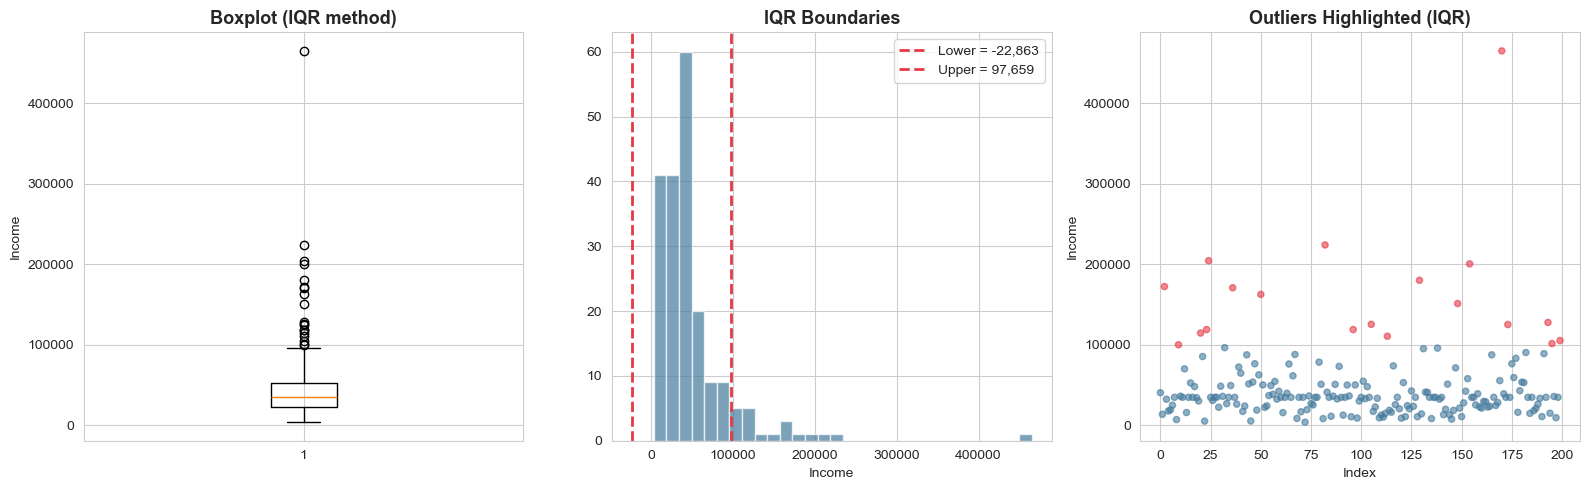

Z-Score outliers (|z| > 3): 4
IQR outliers: 19


In [8]:
# Let's work with income (which is skewed — perfect for outlier demo)
# First, impute missing income values
data['income'] = data['income'].fillna(data['income'].median())

income = data['income']

# Z-Score method
z_scores = np.abs(stats.zscore(income))
outliers_z = z_scores > 3

# IQR method
Q1 = income.quantile(0.25)
Q3 = income.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = (income < lower) | (income > upper)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot
axes[0].boxplot(income, vert=True)
axes[0].set_title('Boxplot (IQR method)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Income')

# Histogram with bounds
axes[1].hist(income, bins=30, color='#457b9d', edgecolor='white', alpha=0.7)
axes[1].axvline(lower, color='#e63946', ls='--', lw=2, label=f'Lower = {lower:,.0f}')
axes[1].axvline(upper, color='#e63946', ls='--', lw=2, label=f'Upper = {upper:,.0f}')
axes[1].set_title('IQR Boundaries', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('Income')

# Scatter with outlier highlights
axes[2].scatter(range(len(income)), income, c=outliers_iqr.map({True: '#e63946', False: '#457b9d'}),
                alpha=0.6, s=20)
axes[2].set_title('Outliers Highlighted (IQR)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('Income')

plt.tight_layout()
plt.show()

print(f"Z-Score outliers (|z| > 3): {outliers_z.sum()}")
print(f"IQR outliers: {outliers_iqr.sum()}")


### Outlier Treatment Options

| Method | How | When |
|--------|-----|------|
| **Remove** | Drop outlier rows | Clearly erroneous data |
| **Cap / Winsorize** | Clip to bounds | Preserve row, reduce effect |
| **Transform** | Log, sqrt | Compress range naturally |
| **Keep** | Do nothing | Outliers are genuine signal |


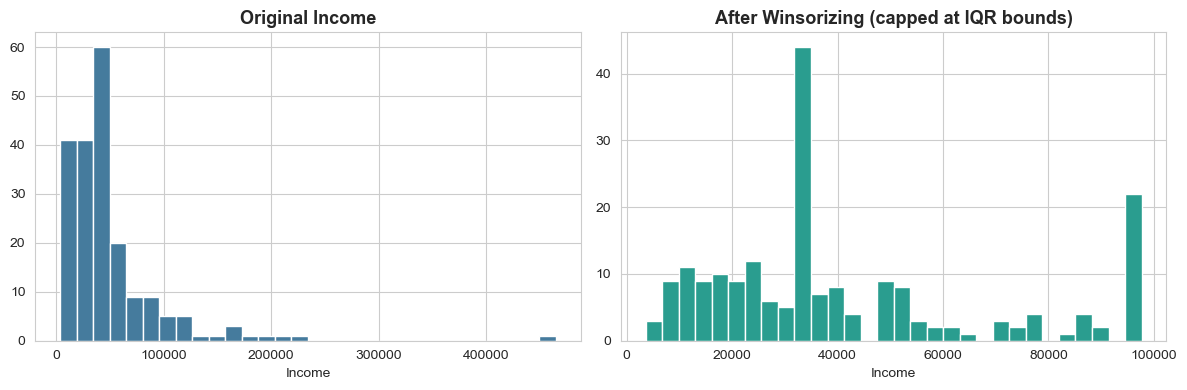

In [9]:
# Winsorizing (capping) — a safe, common approach
income_capped = income.clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(income, bins=30, color='#457b9d', edgecolor='white')
axes[0].set_title('Original Income', fontsize=13, fontweight='bold')
axes[1].hist(income_capped, bins=30, color='#2a9d8f', edgecolor='white')
axes[1].set_title('After Winsorizing (capped at IQR bounds)', fontsize=13, fontweight='bold')
for ax in axes:
    ax.set_xlabel('Income')
plt.tight_layout()
plt.show()


---
# 2. Encoding Categorical Variables

Most ML algorithms need **numbers**, not strings. We must convert categories to numeric representations.

### Decision Guide

```
Is the category ordinal (has a natural order)?
├── Yes → Ordinal Encoding
└── No (nominal)
    ├── ≤ 5-10 categories → One-Hot Encoding
    └── High cardinality → Target Encoding (or Frequency Encoding)
```


## 2.1 Label Encoding
Simply assigns an integer to each category. **Only for ordinal features** where the order matters.


In [10]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Education has a natural order
education_order = ['High School', 'Bachelor', 'Master', 'PhD']

# Using OrdinalEncoder (preserves order)
oe = OrdinalEncoder(categories=[education_order])
data['education_ordinal'] = oe.fit_transform(data[['education']]).astype(int)

print("Ordinal Encoding for Education:")
for cat, val in zip(education_order, range(4)):
    print(f"  {cat:15s} → {val}")

print(f"\nSample:\n{data[['education', 'education_ordinal']].head(8)}")


Ordinal Encoding for Education:
  High School     → 0
  Bachelor        → 1
  Master          → 2
  PhD             → 3

Sample:
     education  education_ordinal
0          PhD                  3
1  High School                  0
2     Bachelor                  1
3          PhD                  3
4     Bachelor                  1
5     Bachelor                  1
6     Bachelor                  1
7     Bachelor                  1


## 2.2 One-Hot Encoding

Creates a **binary column for each category**. Best for nominal (unordered) features with few categories.

$$\text{city} = \text{"Berlin"} \Rightarrow [0, 1, 0, 0, 0]$$

> ⚠️ **Drop one column** to avoid the "dummy variable trap" (perfect multicollinearity in linear models).


In [11]:
# One-Hot Encoding
city_dummies = pd.get_dummies(data['city'], prefix='city', drop_first=True, dtype=int)
print("One-Hot Encoded 'city' (drop_first=True):")
print(city_dummies.head(8))
print(f"\n→ {city_dummies.shape[1]} new columns (one dropped to avoid multicollinearity)")


One-Hot Encoded 'city' (drop_first=True):
   city_London  city_New York  city_Sydney  city_Tokyo
0            0              0            1           0
1            0              0            0           1
2            0              0            1           0
3            1              0            0           0
4            0              0            0           1
5            0              0            0           0
6            0              0            0           1
7            0              1            0           0

→ 4 new columns (one dropped to avoid multicollinearity)


## 2.3 Target Encoding (Mean Encoding)

Replace each category with the **mean of the target** for that category.  
Great for **high-cardinality** features (e.g., zip codes, product IDs).

> ⚠️ **Risk of data leakage!** Always use cross-validation or smoothing.


In [12]:
# Simulate a target variable
data['target'] = (data['income'] > data['income'].median()).astype(int)

# Target encoding for 'city'
target_means = data.groupby('city')['target'].mean()
data['city_target_enc'] = data['city'].map(target_means)

print("Target Encoding for 'city':")
print(target_means.round(3).to_string())
print(f"\nSample:\n{data[['city', 'city_target_enc', 'target']].head(10)}")


Target Encoding for 'city':
city
Berlin      0.415
London      0.471
New York    0.400
Sydney      0.341
Tokyo       0.436

Sample:
       city  city_target_enc  target
0    Sydney         0.341463       1
1     Tokyo         0.435897       0
2    Sydney         0.341463       1
3    London         0.470588       0
4     Tokyo         0.435897       0
5    Berlin         0.414634       0
6     Tokyo         0.435897       0
7  New York         0.400000       0
8     Tokyo         0.435897       0
9  New York         0.400000       1


### Smoothed Target Encoding

To prevent overfitting on rare categories, we blend the category mean with the global mean:

$$	ext{encoded} = rac{n \cdot 	ext{category\_mean} + m \cdot 	ext{global\_mean}}{n + m}$$

where $n$ = count of category, $m$ = smoothing factor (hyperparameter).


In [14]:
# Smoothed target encoding
global_mean = data['target'].mean()
m = 10  # smoothing factor

smooth_enc = data.groupby('city')['target'].agg(['mean', 'count'])
smooth_enc['smoothed'] = (smooth_enc['count'] * smooth_enc['mean'] + m * global_mean) / (smooth_enc['count'] + m)

print("Smoothed Target Encoding (m=10):")
print(smooth_enc.round(3))
print(f"\nGlobal mean: {global_mean:.3f}")
print("💡 Categories with fewer samples are pulled closer to the global mean.")


Smoothed Target Encoding (m=10):
           mean  count  smoothed
city                            
Berlin    0.415     41     0.414
London    0.471     34     0.457
New York  0.400     45     0.402
Sydney    0.341     41     0.355
Tokyo     0.436     39     0.431

Global mean: 0.410
💡 Categories with fewer samples are pulled closer to the global mean.


## 2.4 Frequency Encoding

Replace each category with how often it appears. Simple, no data leakage, works surprisingly well.


In [15]:
freq = data['city'].value_counts(normalize=True)
data['city_freq'] = data['city'].map(freq)

print("Frequency Encoding for 'city':")
print(freq.round(3).to_string())


Frequency Encoding for 'city':
city
New York    0.225
Sydney      0.205
Berlin      0.205
Tokyo       0.195
London      0.170


### Encoding Comparison — Visual Summary

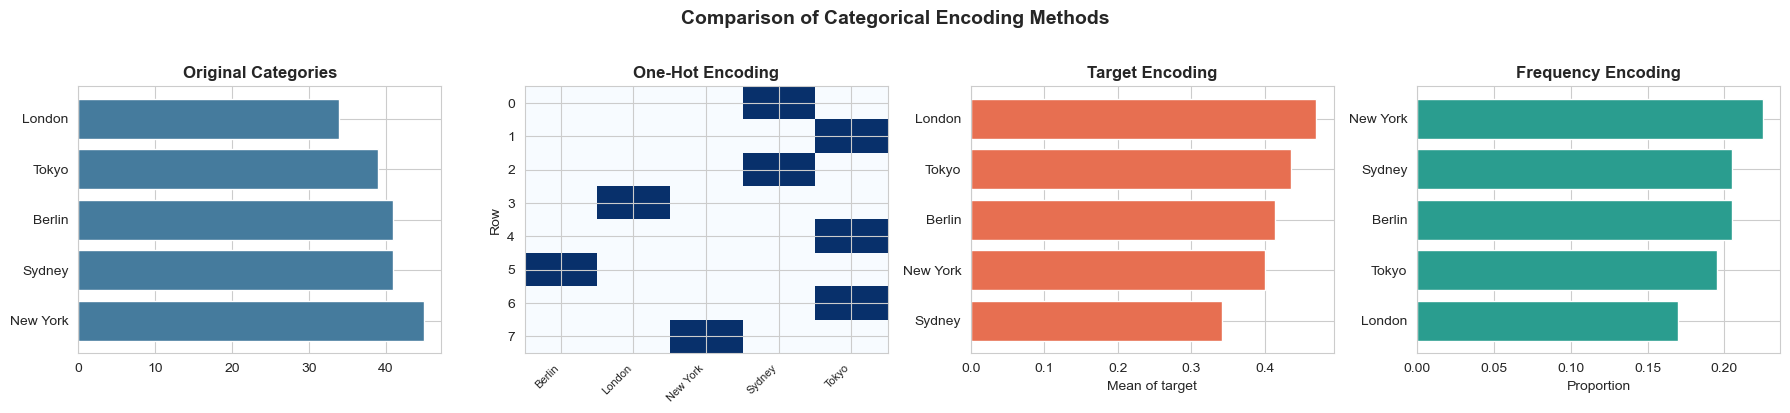

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Original categories
cats = data['city'].value_counts()
axes[0].barh(cats.index, cats.values, color='#457b9d')
axes[0].set_title('Original Categories', fontweight='bold')

# One-hot (show matrix)
ohe_sample = pd.get_dummies(data['city'], dtype=int).head(8)
axes[1].imshow(ohe_sample.values, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(ohe_sample.columns)))
axes[1].set_xticklabels(ohe_sample.columns, rotation=45, ha='right', fontsize=8)
axes[1].set_title('One-Hot Encoding', fontweight='bold')
axes[1].set_ylabel('Row')

# Target encoding
te = data.groupby('city')['target'].mean().sort_values()
axes[2].barh(te.index, te.values, color='#e76f51')
axes[2].set_title('Target Encoding', fontweight='bold')
axes[2].set_xlabel('Mean of target')

# Frequency encoding
fe = data['city'].value_counts(normalize=True).sort_values()
axes[3].barh(fe.index, fe.values, color='#2a9d8f')
axes[3].set_title('Frequency Encoding', fontweight='bold')
axes[3].set_xlabel('Proportion')

plt.suptitle('Comparison of Categorical Encoding Methods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# 3. Feature Scaling

Many algorithms (SVM, KNN, Neural Networks, Gradient Descent) are sensitive to the **scale** of features.  
If "income" ranges 20,000–200,000 and "age" ranges 18–70, the model will be dominated by income.

### Three Main Scalers

| Scaler | Formula | Range | Best When |
|--------|---------|-------|-----------|
| **StandardScaler** | $z = \frac{x - \mu}{\sigma}$ | ~ [-3, 3] | Data is roughly normal |
| **MinMaxScaler** | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$ | [0, 1] | Need bounded range (e.g., neural nets) |
| **RobustScaler** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | varies | Data has outliers |


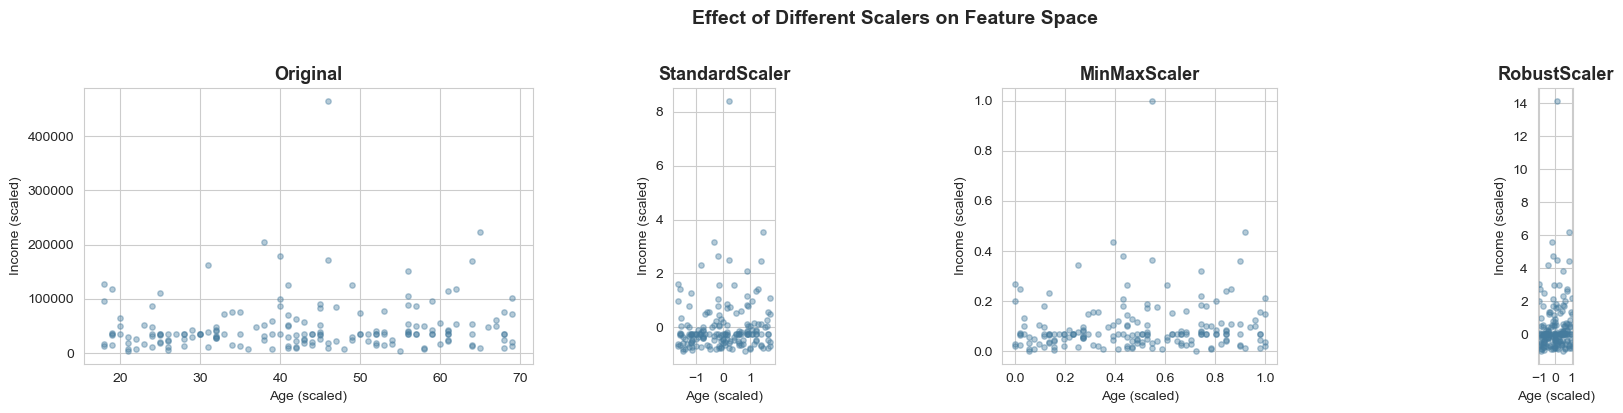

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Use income and age for comparison
features = data[['age', 'income']].dropna()

scalers = {
    'Original': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, scaler) in zip(axes, scalers.items()):
    if scaler is None:
        vals = features.values
    else:
        vals = scaler.fit_transform(features)
    
    ax.scatter(vals[:, 0], vals[:, 1], alpha=0.4, s=15, c='#457b9d')
    ax.set_xlabel('Age (scaled)')
    ax.set_ylabel('Income (scaled)')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_aspect('equal' if scaler else 'auto')

plt.suptitle('Effect of Different Scalers on Feature Space', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### When to scale (and when not to)

| Algorithm | Needs Scaling? | Why |
|-----------|---------------|-----|
| Linear/Logistic Regression | ✅ Yes (for regularization) | Coefficients penalized equally |
| SVM | ✅ Yes | Distance-based |
| KNN | ✅ Yes | Distance-based |
| Neural Networks | ✅ Yes | Gradient descent convergence |
| Decision Trees | ❌ No | Split thresholds are scale-invariant |
| Random Forest | ❌ No | Ensemble of trees |
| XGBoost/LightGBM | ❌ No | Tree-based |

> **Important:** Always fit the scaler on the **training set** only, then transform both train and test.


---
# 4. Feature Transformations

Some features have **skewed distributions** that can hurt model performance (especially linear models).  
Transformations can make data more "normal-like".

### Common Transformations

| Transform | Formula | Use When |
|-----------|---------|----------|
| **Log** | $x' = \log(x + 1)$ | Right-skewed, positive values |
| **Square Root** | $x' = \sqrt{x}$ | Count data |
| **Box-Cox** | $x' = \frac{x^\lambda - 1}{\lambda}$ | Positive values, auto-finds best $\lambda$ |
| **Yeo-Johnson** | Extension of Box-Cox | Works with negative values too |


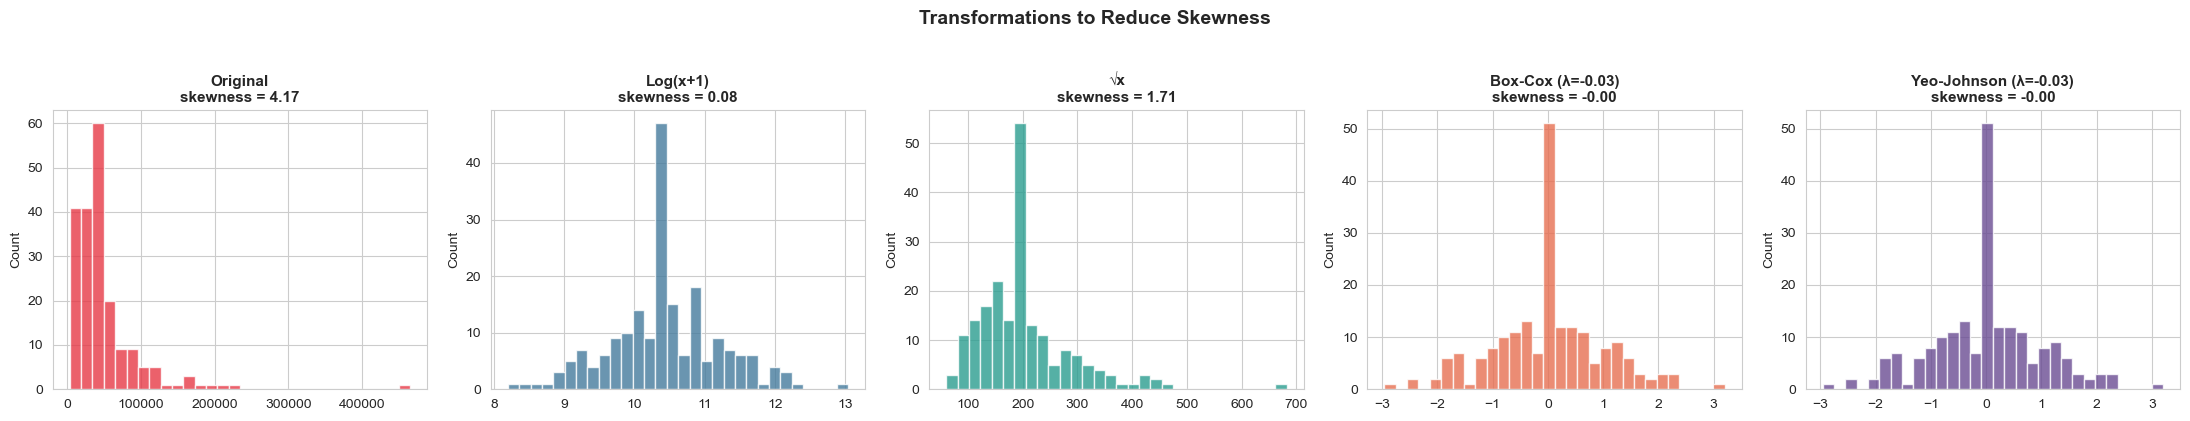

💡 Goal: Reduce skewness closer to 0 (symmetric distribution).
   Box-Cox and Yeo-Johnson automatically find the best λ.


In [18]:
from sklearn.preprocessing import PowerTransformer

income = data['income'].dropna()

# Apply transformations
log_income = np.log1p(income)
sqrt_income = np.sqrt(income)

pt_bc = PowerTransformer(method='box-cox')
bc_income = pt_bc.fit_transform(income.values.reshape(-1, 1)).ravel()

pt_yj = PowerTransformer(method='yeo-johnson')
yj_income = pt_yj.fit_transform(income.values.reshape(-1, 1)).ravel()

# Visualize all transformations
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
transforms = [
    ('Original', income, '#e63946'),
    ('Log(x+1)', log_income, '#457b9d'),
    ('√x', sqrt_income, '#2a9d8f'),
    (f'Box-Cox (λ={pt_bc.lambdas_[0]:.2f})', bc_income, '#e76f51'),
    (f'Yeo-Johnson (λ={pt_yj.lambdas_[0]:.2f})', yj_income, '#6a4c93'),
]

for ax, (title, vals, color) in zip(axes, transforms):
    ax.hist(vals, bins=30, color=color, edgecolor='white', alpha=0.8)
    skew = pd.Series(vals).skew()
    ax.set_title(f'{title}\nskewness = {skew:.2f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Transformations to Reduce Skewness', fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print("💡 Goal: Reduce skewness closer to 0 (symmetric distribution).")
print("   Box-Cox and Yeo-Johnson automatically find the best λ.")


---
# 5. Feature Creation (Feature Engineering)

This is where the **art** of data science lives. Creating new features from existing ones can dramatically improve model performance.

> "Coming up with features is difficult, time-consuming, requires expert knowledge.  
> Applied machine learning is basically feature engineering." — Andrew Ng

---
## 5.1 Interaction Features

Capture the **combined effect** of two features that the model might not learn on its own.

$$x_{\text{new}} = x_1 \times x_2$$


In [19]:
# Impute remaining missing values for clean feature engineering
data['age'] = data['age'].fillna(data['age'].median())
data['experience_years'] = data['experience_years'].fillna(data['experience_years'].median())
data['satisfaction'] = data['satisfaction'].fillna(data['satisfaction'].median())

# Interaction features
data['age_x_experience'] = data['age'] * data['experience_years']
data['income_per_year_exp'] = data['income'] / (data['experience_years'] + 1)  # +1 to avoid /0

print("New interaction features:")
print(data[['age', 'experience_years', 'age_x_experience', 'income', 'income_per_year_exp']].head(8))


New interaction features:
    age  experience_years  age_x_experience         income  \
0  56.0               1.0              56.0   40199.498182   
1  69.0              12.0             828.0   13365.673522   
2  46.0              29.0            1334.0  172145.011651   
3  32.0              10.0             320.0   32123.105060   
4  60.0              10.0             600.0   17578.119892   
5  25.0              15.0             375.0   18884.876129   
6  38.0              10.0             380.0   24673.914144   
7  56.0              15.0             840.0   34492.512806   

   income_per_year_exp  
0         20099.749091  
1          1028.128732  
2          5738.167055  
3          2920.282278  
4          1598.010899  
5          1180.304758  
6          2243.083104  
7          2155.782050  


## 5.2 Polynomial Features

Add squared and cross terms to capture **non-linear relationships**.

For features $[x_1, x_2]$ with degree=2:  
$$[1, x_1, x_2, x_1^2, x_1 x_2, x_2^2]$$


In [20]:
from sklearn.preprocessing import PolynomialFeatures

# Demo with 2 features
X_demo = data[['age', 'experience_years']].head(5)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_demo)

print("Original features: age, experience_years")
print(f"Polynomial features ({X_poly.shape[1]} total):")
print(f"Names: {poly.get_feature_names_out()}")
print(f"\nSample:\n{pd.DataFrame(X_poly, columns=poly.get_feature_names_out()).head()}")


Original features: age, experience_years
Polynomial features (5 total):
Names: ['age' 'experience_years' 'age^2' 'age experience_years'
 'experience_years^2']

Sample:
    age  experience_years   age^2  age experience_years  experience_years^2
0  56.0               1.0  3136.0                  56.0                 1.0
1  69.0              12.0  4761.0                 828.0               144.0
2  46.0              29.0  2116.0                1334.0               841.0
3  32.0              10.0  1024.0                 320.0               100.0
4  60.0              10.0  3600.0                 600.0               100.0


## 5.3 Binning / Discretization

Convert continuous features into **discrete bins**. Useful when the relationship with the target is step-like rather than linear.


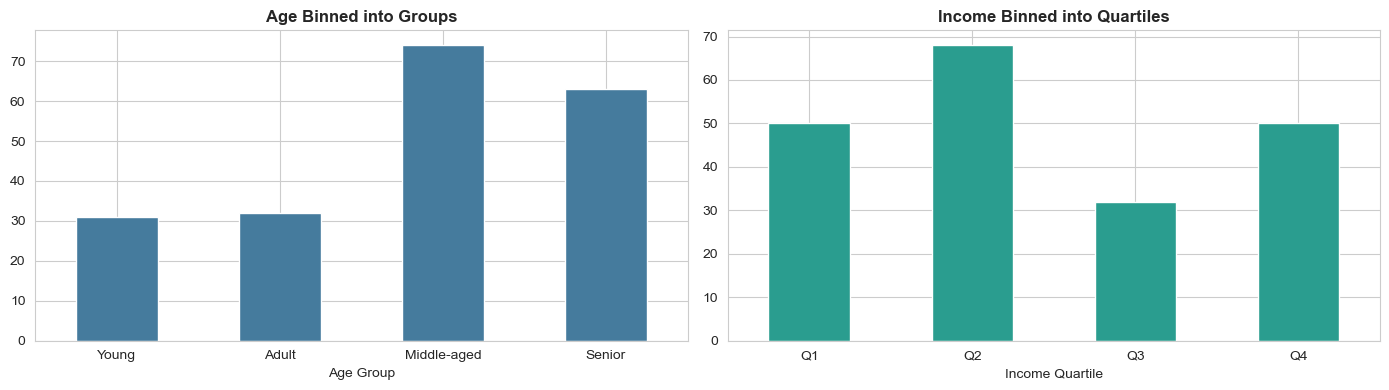

💡 Equal-width bins (pd.cut): useful when distribution is uniform
💡 Quantile bins (pd.qcut): each bin has ~same number of samples (better for skewed data)


In [21]:
from sklearn.preprocessing import KBinsDiscretizer

# Bin age into groups
data['age_group'] = pd.cut(data['age'], 
                           bins=[0, 25, 35, 50, 100], 
                           labels=['Young', 'Adult', 'Middle-aged', 'Senior'])

# Also try quantile-based binning
data['income_quartile'] = pd.qcut(data['income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#457b9d', edgecolor='white')
axes[0].set_title('Age Binned into Groups', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=0)

data['income_quartile'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#2a9d8f', edgecolor='white')
axes[1].set_title('Income Binned into Quartiles', fontweight='bold')
axes[1].set_xlabel('Income Quartile')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("💡 Equal-width bins (pd.cut): useful when distribution is uniform")
print("💡 Quantile bins (pd.qcut): each bin has ~same number of samples (better for skewed data)")


## 5.4 Date/Time Feature Engineering

Dates are goldmines of features! From a single datetime column you can extract:


In [22]:
# Create sample datetime data
dates = pd.date_range('2023-01-01', periods=200, freq='D')
df_time = pd.DataFrame({'date': dates[:len(data)]})

# Extract features from datetime
df_time['year'] = df_time['date'].dt.year
df_time['month'] = df_time['date'].dt.month
df_time['day_of_week'] = df_time['date'].dt.dayofweek          # 0=Monday
df_time['day_of_year'] = df_time['date'].dt.dayofyear
df_time['is_weekend'] = df_time['date'].dt.dayofweek.isin([5, 6]).astype(int)
df_time['quarter'] = df_time['date'].dt.quarter
df_time['is_month_start'] = df_time['date'].dt.is_month_start.astype(int)
df_time['is_month_end'] = df_time['date'].dt.is_month_end.astype(int)

# Cyclical encoding for month (so Dec and Jan are close)
df_time['month_sin'] = np.sin(2 * np.pi * df_time['month'] / 12)
df_time['month_cos'] = np.cos(2 * np.pi * df_time['month'] / 12)

print("Date/Time Features:")
print(df_time.head(10))


Date/Time Features:
        date  year  month  day_of_week  day_of_year  is_weekend  quarter  \
0 2023-01-01  2023      1            6            1           1        1   
1 2023-01-02  2023      1            0            2           0        1   
2 2023-01-03  2023      1            1            3           0        1   
3 2023-01-04  2023      1            2            4           0        1   
4 2023-01-05  2023      1            3            5           0        1   
5 2023-01-06  2023      1            4            6           0        1   
6 2023-01-07  2023      1            5            7           1        1   
7 2023-01-08  2023      1            6            8           1        1   
8 2023-01-09  2023      1            0            9           0        1   
9 2023-01-10  2023      1            1           10           0        1   

   is_month_start  is_month_end  month_sin  month_cos  
0               1             0        0.5   0.866025  
1               0             0

### Why Cyclical Encoding?

Months are **cyclical**: December (12) is close to January (1), but numerically 12 and 1 are far apart.  
Sine/cosine encoding places them on a circle:

$$x_{\sin} = \sin\left(\frac{2\pi \cdot \text{month}}{12}\right), \quad x_{\cos} = \cos\left(\frac{2\pi \cdot \text{month}}{12}\right)$$


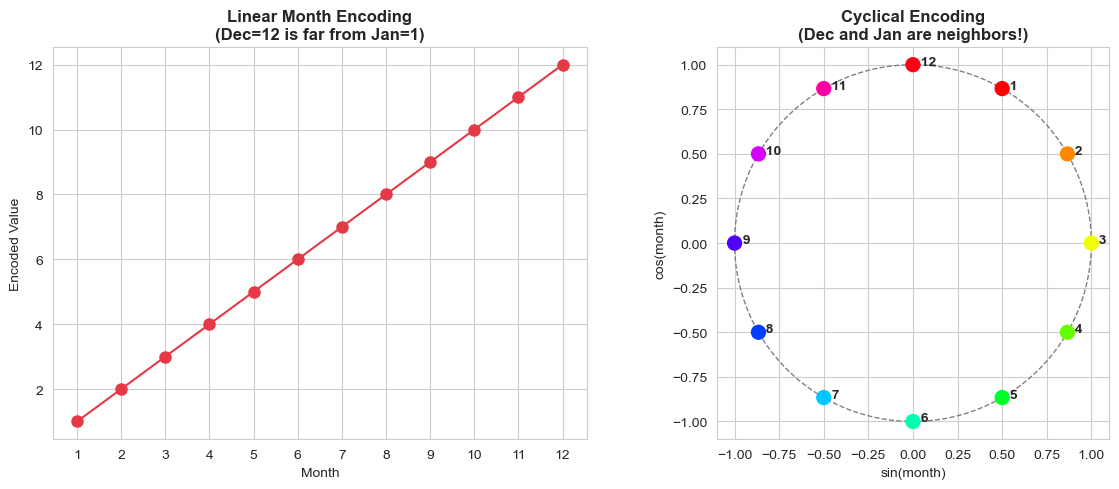

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear vs Cyclical
months = np.arange(1, 13)
axes[0].plot(months, months, 'o-', color='#e63946', markersize=8)
axes[0].set_title('Linear Month Encoding\n(Dec=12 is far from Jan=1)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Encoded Value')
axes[0].set_xticks(months)

# Cyclical
sin_vals = np.sin(2 * np.pi * months / 12)
cos_vals = np.cos(2 * np.pi * months / 12)
axes[1].scatter(sin_vals, cos_vals, c=months, cmap='hsv', s=100, zorder=5)
for m, s, c in zip(months, sin_vals, cos_vals):
    axes[1].annotate(f'  {m}', (s, c), fontsize=10, fontweight='bold')
circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--')
axes[1].add_patch(circle)
axes[1].set_aspect('equal')
axes[1].set_title('Cyclical Encoding\n(Dec and Jan are neighbors!)', fontweight='bold')
axes[1].set_xlabel('sin(month)')
axes[1].set_ylabel('cos(month)')

plt.tight_layout()
plt.show()


## 5.5 Text-Based Feature Engineering (Basics)

From a text column, you can quickly extract useful numeric features:


In [24]:
# Sample text data
texts = [
    "Great product! Highly recommend it.",
    "Terrible service. Never again!!!",
    "It was okay, nothing special.",
    "AMAZING!! Best purchase I've ever made!!! :)",
    "meh",
]

df_text = pd.DataFrame({'review': texts})

# Simple text features (no NLP libraries needed)
df_text['char_count'] = df_text['review'].str.len()
df_text['word_count'] = df_text['review'].str.split().str.len()
df_text['avg_word_length'] = df_text['review'].apply(lambda x: np.mean([len(w) for w in x.split()]))
df_text['exclamation_count'] = df_text['review'].str.count('!')
df_text['question_count'] = df_text['review'].str.count('\?')
df_text['uppercase_ratio'] = df_text['review'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x))
df_text['has_emoji'] = df_text['review'].str.contains('[😊😃🙂😢😡:)(]', regex=True).astype(int)

print(df_text.to_string(index=False))


                                      review  char_count  word_count  avg_word_length  exclamation_count  question_count  uppercase_ratio  has_emoji
         Great product! Highly recommend it.          35           5         6.200000                  1               0         0.057143          0
            Terrible service. Never again!!!          32           4         7.250000                  3               0         0.062500          0
               It was okay, nothing special.          29           5         5.000000                  0               0         0.034483          0
AMAZING!! Best purchase I've ever made!!! :)          44           7         5.428571                  5               0         0.204545          1
                                         meh           3           1         3.000000                  0               0         0.000000          0


---
# 6. Feature Selection

Not all features are helpful. **Too many features** can cause:
- Overfitting (model memorizes noise)
- Slow training
- Curse of dimensionality

### Three Approaches

| Approach | Method | Speed | Quality |
|----------|--------|-------|---------|
| **Filter** | Statistical tests (correlation, mutual info) | ⚡ Fast | Good |
| **Wrapper** | Try subsets, evaluate model (RFE) | 🐢 Slow | Best |
| **Embedded** | Model learns importance (Lasso, tree importance) | ⚡ Fast | Great |


## 6.1 Filter Methods: Correlation Analysis

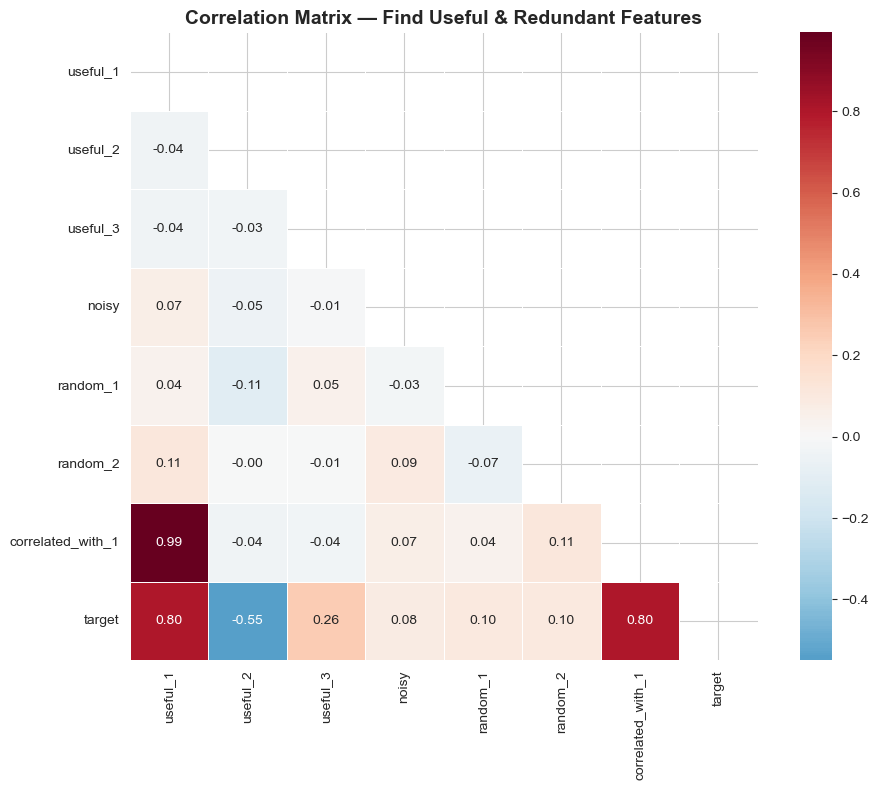

💡 Observations:
  - useful_1, useful_2, useful_3 correlate with target (good!)
  - correlated_with_1 is redundant (r=0.99 with useful_1)
  - noisy, random_1, random_2 don't correlate with target (drop candidates)


In [25]:
# Create a dataset with numeric features for selection demo
np.random.seed(42)
n = 300
X = pd.DataFrame({
    'useful_1': np.random.randn(n),
    'useful_2': np.random.randn(n),
    'useful_3': np.random.randn(n),
    'noisy': np.random.randn(n),
    'random_1': np.random.randn(n),
    'random_2': np.random.randn(n),
    'correlated_with_1': None,  # placeholder
})
X['correlated_with_1'] = X['useful_1'] * 0.9 + np.random.randn(n) * 0.1

# Target depends on useful features
y = 3 * X['useful_1'] - 2 * X['useful_2'] + X['useful_3'] + np.random.randn(n) * 0.5

X_with_target = X.copy()
X_with_target['target'] = y

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = X_with_target.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Find Useful & Redundant Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Observations:")
print("  - useful_1, useful_2, useful_3 correlate with target (good!)")
print("  - correlated_with_1 is redundant (r=0.99 with useful_1)")
print("  - noisy, random_1, random_2 don't correlate with target (drop candidates)")


## 6.2 Filter Methods: Mutual Information

Unlike correlation, mutual information captures **non-linear** relationships.


$$MI(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x) \, p(y)}$$

- MI = 0 → features are independent  
- Higher MI → stronger relationship (linear or non-linear)


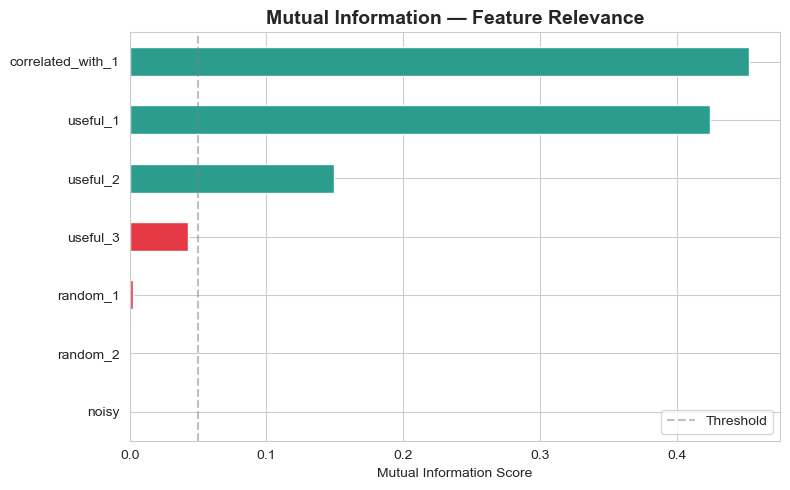

💡 Red bars: low MI → candidates for removal
   Green bars: high MI → keep these features


In [26]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#e63946' if v < 0.05 else '#2a9d8f' for v in mi_series.values]
mi_series.plot(kind='barh', color=colors)
plt.xlabel('Mutual Information Score')
plt.title('Mutual Information — Feature Relevance', fontsize=14, fontweight='bold')
plt.axvline(0.05, color='gray', ls='--', alpha=0.5, label='Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("💡 Red bars: low MI → candidates for removal")
print("   Green bars: high MI → keep these features")


## 6.3 Wrapper Method: Recursive Feature Elimination (RFE)

RFE trains a model repeatedly, removing the **least important feature** each time.


In [27]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(model, n_features_to_select=3, step=1)
rfe.fit(X, y)

# Results
rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("RFE Results (top 3 selected):")
print(rfe_results.to_string(index=False))
print("\n💡 RFE correctly identified useful_1, useful_2, useful_3 as the top features!")


RFE Results (top 3 selected):
          Feature  Selected  Ranking
         useful_1      True        1
         useful_2      True        1
         useful_3      True        1
correlated_with_1     False        2
         random_1     False        3
         random_2     False        4
            noisy     False        5

💡 RFE correctly identified useful_1, useful_2, useful_3 as the top features!


## 6.4 Embedded Method: Lasso (L1 Regularization)

Lasso regression automatically sets irrelevant feature coefficients to **exactly zero**.


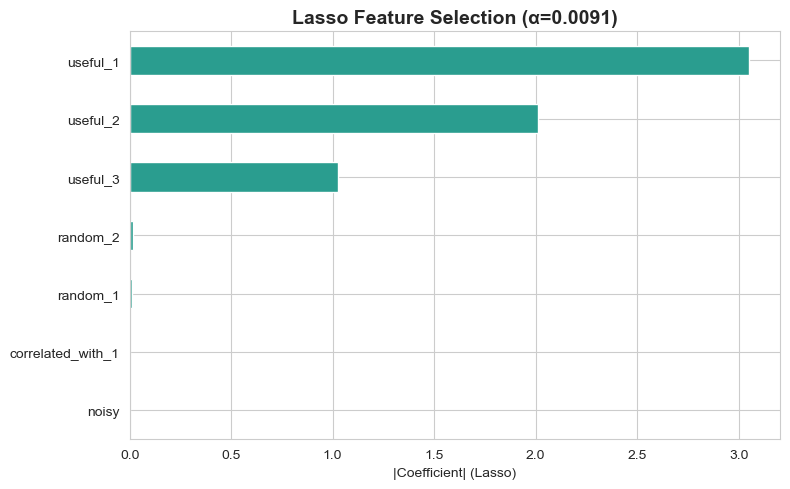

Features with near-zero coefficients (Lasso dropped): ['noisy', 'correlated_with_1']
💡 Lasso automatically performs feature selection by shrinking useless features to zero.


In [28]:
from sklearn.linear_model import LassoCV

# Fit Lasso with cross-validation to find best alpha
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)

# Feature importance = |coefficient|
coefs = pd.Series(np.abs(lasso.coef_), index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#e63946' if v < 0.01 else '#2a9d8f' for v in coefs.values]
coefs.plot(kind='barh', color=colors)
plt.xlabel('|Coefficient| (Lasso)')
plt.title(f'Lasso Feature Selection (α={lasso.alpha_:.4f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

zero_features = coefs[coefs < 0.01].index.tolist()
print(f"Features with near-zero coefficients (Lasso dropped): {zero_features}")
print("💡 Lasso automatically performs feature selection by shrinking useless features to zero.")


---
# 7. Putting It All Together — Sklearn Pipelines

In practice, you chain preprocessing + feature engineering + model into a **Pipeline** to:
- Prevent data leakage (scaler fit only on train)
- Reproduce the same steps on new data
- Make code cleaner and less error-prone


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Rebuild a clean dataset
np.random.seed(42)
n = 300
df_pipeline = pd.DataFrame({
    'age': np.random.randint(18, 70, n).astype(float),
    'income': np.random.lognormal(10.5, 0.8, n),
    'experience': np.random.randint(0, 30, n).astype(float),
    'city': np.random.choice(['NYC', 'London', 'Berlin', 'Tokyo'], n),
    'education': np.random.choice(['HS', 'BS', 'MS', 'PhD'], n),
})
# Inject some missing
rng = np.random.default_rng(42)
df_pipeline.loc[rng.choice(n, 20, replace=False), 'age'] = np.nan
df_pipeline.loc[rng.choice(n, 15, replace=False), 'income'] = np.nan

y_pipeline = 0.5 * df_pipeline['age'].fillna(30) + 0.3 * df_pipeline['income'].fillna(40000) + np.random.randn(n) * 5000

# Define column types
numeric_features = ['age', 'income', 'experience']
categorical_features = ['city', 'education']

# Numeric pipeline: impute → scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Categorical pipeline: impute → one-hot
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

# Full pipeline: preprocess → model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42)),
])

# Cross-validate
scores = cross_val_score(full_pipeline, df_pipeline, y_pipeline, cv=5, scoring='r2')

print("Full Pipeline: Impute → Scale → Encode → Random Forest")
print(f"Cross-validation R² scores: {scores.round(3)}")
print(f"Mean R²: {scores.mean():.3f} ± {scores.std():.3f}")
print("\n💡 The pipeline ensures no data leakage: scaler & encoder fit only on training folds!")


Full Pipeline: Impute → Scale → Encode → Random Forest
Cross-validation R² scores: [0.86  0.74  0.841 0.65  0.736]
Mean R²: 0.765 ± 0.077

💡 The pipeline ensures no data leakage: scaler & encoder fit only on training folds!


### Pipeline Visualization

In [30]:
from sklearn import set_config
set_config(display='text')
print(full_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income',
                                                   'experience']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
             

---
# 📋 Feature Engineering Cheat Sheet

| Technique | When to Use | Watch Out For |
|-----------|------------|---------------|
| Mean/Median Imputation | MCAR, simple baseline | Distorts variance |
| KNN Imputation | MAR, features correlated | Slow on large datasets |
| Missingness Indicator | MNAR suspected | Adds extra column |
| One-Hot Encoding | Nominal, few categories | Curse of dimensionality |
| Ordinal Encoding | Ordered categories | Wrong order = wrong signal |
| Target Encoding | High cardinality | Data leakage! Use smoothing + CV |
| StandardScaler | Normal-ish data | Outliers affect mean/std |
| RobustScaler | Data with outliers | Less common in practice |
| Log Transform | Right-skewed positive data | Doesn't work with zeros/negatives |
| Box-Cox / Yeo-Johnson | Auto-find best transform | Box-Cox needs positive values |
| Polynomial Features | Non-linear relationships | Explosive feature count |
| Binning | Step-like relationships | Loses information |
| Cyclical Encoding | Time features (hour, month) | Need both sin AND cos |
| RFE | Model-based selection | Slow with many features |
| Lasso | Linear feature selection | Only linear relationships |
| Mutual Information | Any relationship type | Noisy with small samples |

---


---
# 🎯 Interview Questions & Answers

---

### Q1: What is feature engineering and why is it important?

**A:** Feature engineering is the process of creating, transforming, and selecting input variables (features) to improve model performance. It's often the **biggest lever** for model improvement — a simple model with great features usually beats a complex model with raw features. It encodes domain knowledge into the data.

---

### Q2: How do you handle missing data? What's the difference between MCAR, MAR, and MNAR?

**A:**  
- **MCAR** (Missing Completely At Random): Missingness is random, unrelated to any variable. Safe to drop rows.  
- **MAR** (Missing At Random): Missingness depends on observed data (e.g., younger people skip a question). Use imputation based on related features.  
- **MNAR** (Missing Not At Random): Missingness depends on the missing value itself (e.g., high earners hide income). Add a missingness indicator flag.

**Strategies**: mean/median (simple), KNN imputer (uses neighbors), MICE/iterative (models each feature), or domain-specific rules.

---

### Q3: When would you use one-hot encoding vs. target encoding?

**A:**  
- **One-Hot**: For nominal features with ≤10 categories. Creates binary columns. Safe, no leakage.  
- **Target Encoding**: For high-cardinality features (100+ categories like zip codes). Replaces category with mean target. **Risk**: data leakage → always use smoothing + cross-validation.

---

### Q4: Why do we need feature scaling? Which algorithms require it?

**A:** Algorithms that compute distances or use gradient descent are affected by feature scale. **Need scaling**: SVM, KNN, Neural Networks, Linear/Logistic Regression (with regularization), PCA. **Don't need scaling**: Tree-based methods (Decision Trees, Random Forest, XGBoost) because they split on thresholds, not distances.

---

### Q5: What is the "dummy variable trap" and how do you avoid it?

**A:** When you one-hot encode a feature with $k$ categories, $k$ binary columns are perfectly multicollinear (they sum to 1). This causes problems for linear models (matrix is singular). **Fix**: drop one column (`drop_first=True`), creating $k-1$ columns. Tree-based models are not affected.

---

### Q6: Explain the difference between StandardScaler and RobustScaler.

**A:**  
- **StandardScaler**: Uses mean and standard deviation → $z = (x - \mu) / \sigma$. Sensitive to outliers.
- **RobustScaler**: Uses median and IQR → $z = (x - Q_2) / (Q_3 - Q_1)$. Robust to outliers because median/IQR are not affected by extreme values.

---

### Q7: What is data leakage in feature engineering? Give an example.

**A:** Data leakage occurs when information from the test/future data "leaks" into training. Examples:  
- Fitting a scaler on the entire dataset (train + test) before splitting.
- Target encoding without cross-validation (target mean includes test data).  
- Using future timestamps to engineer features for past predictions.  

**Fix**: Always fit transformers on training data only. Use **sklearn Pipelines** with cross-validation.

---

### Q8: How do you handle a categorical feature with 10,000+ unique values?

**A:** Options:  
1. **Target encoding** (with smoothing + CV)
2. **Frequency encoding** (replace with occurrence count)
3. **Group rare categories** into "Other" (keep top N)
4. **Embedding layers** (in neural networks)
5. **Hashing trick** (fixed-size vector)

---

### Q9: When and why would you use log transformation?

**A:** For **right-skewed** positive features (e.g., income, prices, counts). Log compression makes the distribution more symmetric, which helps:
- Linear models (assumes normal residuals)
- Stabilize variance
- Reduce outlier influence

Use `np.log1p(x)` to handle zeros. Cannot use for negative values (use Yeo-Johnson instead).

---

### Q10: What is cyclical encoding and when do you use it?

**A:** For features that **wrap around** — hours (23→0), months (Dec→Jan), day of week (Sun→Mon). Simple integer encoding makes Dec (12) and Jan (1) seem far apart. Cyclical encoding maps to a circle using:

$$x_{\sin} = \sin(2\pi \cdot x / \text{period}), \quad x_{\cos} = \cos(2\pi \cdot x / \text{period})$$

You need **both** sin and cos (one alone is ambiguous — sin(3am) = sin(9pm)).

---

### Q11: How would you approach feature engineering for a new ML project?

**A:** Step-by-step:
1. **EDA**: Understand distributions, correlations, missing patterns
2. **Clean**: Handle missing values, duplicates, outliers
3. **Encode**: Convert categoricals appropriately
4. **Transform**: Fix skewed distributions
5. **Create**: Domain-specific features, interactions, time features
6. **Select**: Remove irrelevant/redundant features (correlation, MI, RFE)
7. **Pipeline**: Wrap everything in an sklearn Pipeline
8. **Iterate**: Try features, evaluate with CV, keep what helps

---

### Q12: What is the difference between filter, wrapper, and embedded feature selection?

**A:**
- **Filter**: Rank features by statistical measure (correlation, MI, chi-squared). Fast, model-agnostic.
- **Wrapper**: Evaluate subsets with an actual model (RFE, forward/backward selection). Slow but best results.
- **Embedded**: Model performs selection during training (Lasso L1, tree feature importance). Fast and effective.

**In practice**: Start with filter (remove obvious junk), then use embedded (Lasso or tree importance) for final selection.

---


---
*Created for [Machine Learning Explorations](https://github.com/Zhanarik/Machine-Learning) — Happy learning!* 🚀
